
📌 First 5 rows:
         Date        Time State     Group  Unit  Sales
0  1-Oct-2020     Morning    WA      Kids     8  20000
1  1-Oct-2020     Morning    WA       Men     8  20000
2  1-Oct-2020     Morning    WA     Women     4  10000
3  1-Oct-2020     Morning    WA   Seniors    15  37500
4  1-Oct-2020   Afternoon    WA      Kids     3   7500

📌 Column names:
['Date', 'Time', 'State', 'Group', 'Unit', 'Sales']

📌 Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    7560 non-null   object
 1   Time    7560 non-null   object
 2   State   7560 non-null   object
 3   Group   7560 non-null   object
 4   Unit    7560 non-null   int64 
 5   Sales   7560 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 354.5+ KB
None

📌 Missing values:
Date     0
Time     0
State    0
Group    0
Unit     0
Sales    0
dtype: int64

📊 Sales Descriptive Stati

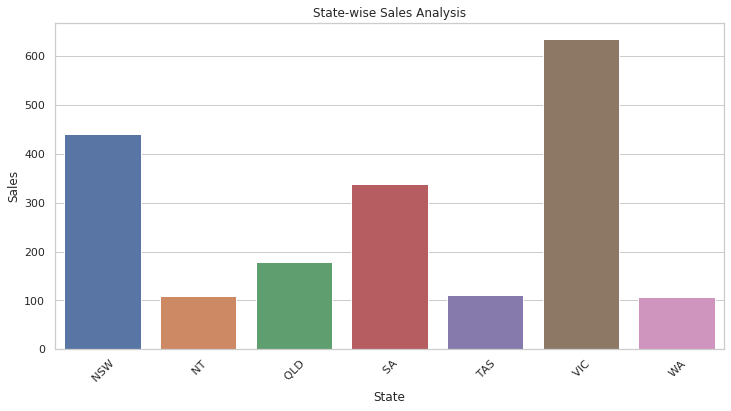

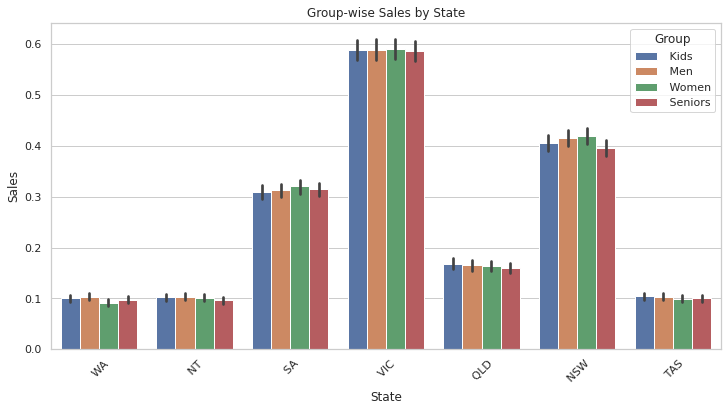

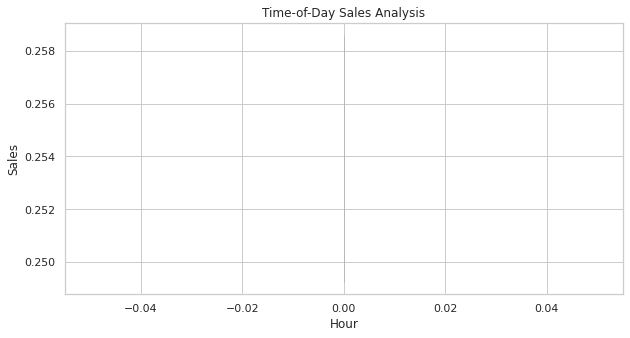

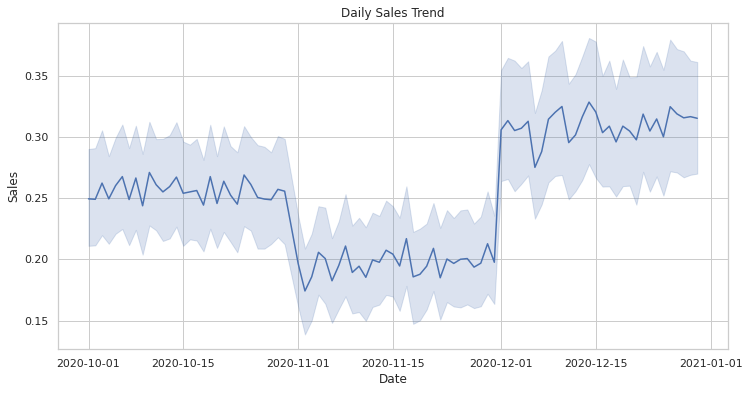

TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

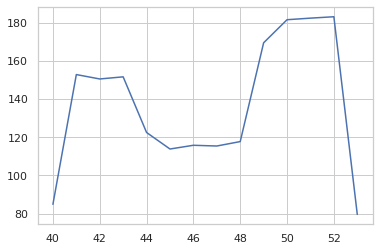

In [9]:
# ---------------------------------------------------------
# 📌 Sales Analysis Project - AAL Clothing Brand
# ---------------------------------------------------------

# Step 1: Import required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Step 2: Load dataset (use your actual file name)
df = pd.read_csv("AusApparalSales4thQrt2020.csv")

# Inspect dataset
print("\n📌 First 5 rows:")
print(df.head())

print("\n📌 Column names:")
print(df.columns.tolist())

print("\n📌 Info:")
print(df.info())

print("\n📌 Missing values:")
print(df.isna().sum())

# Step 3: Handle missing values (choose drop or fill)
df = df.dropna()  # OR use: df.fillna(method='ffill', inplace=True)

# Step 4: Normalization (only normalize existing numeric columns)
scaler = MinMaxScaler()

# Normalize only 'Sales'
if "Sales" in df.columns:
    df[['Sales']] = scaler.fit_transform(df[['Sales']])

# If dataset also has units-like column (edit the name once you know it)
for col in ["Units", "Quantity", "Units_Sold"]:
    if col in df.columns:
        df[[col]] = scaler.fit_transform(df[[col]])

# Step 5: Convert date column
if "Date" in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df['Week'] = df['Date'].dt.isocalendar().week
    df['Month'] = df['Date'].dt.month
    df['Quarter'] = df['Date'].dt.quarter
    df['Hour'] = df['Date'].dt.hour

# ---------------------------------------------------------
# 2. DATA ANALYSIS
# ---------------------------------------------------------

# Descriptive statistics for Sales
if "Sales" in df.columns:
    print("\n📊 Sales Descriptive Statistics")
    print("Mean:", df['Sales'].mean())
    print("Median:", df['Sales'].median())
    print("Mode:", df['Sales'].mode()[0])
    print("Std Dev:", df['Sales'].std())

# Grouping: State-wise sales
if "State" in df.columns and "Sales" in df.columns:
    state_sales = df.groupby("State")['Sales'].sum().reset_index()
    print("\n📊 State-wise Sales:\n", state_sales)

    highest_sales = state_sales.loc[state_sales['Sales'].idxmax()]
    lowest_sales = state_sales.loc[state_sales['Sales'].idxmin()]
    print("\n✅ Highest Sales State:", highest_sales)
    print("✅ Lowest Sales State:", lowest_sales)

# Grouping: Group-wise sales (Kids, Men, Women, Seniors)
if "Group" in df.columns and "Sales" in df.columns:
    group_sales = df.groupby("Group")['Sales'].sum().reset_index()
    print("\n📊 Group-wise Sales:\n", group_sales)

# Weekly, Monthly, Quarterly reports
if "Date" in df.columns:
    weekly_report = df.groupby('Week')['Sales'].sum().reset_index()
    monthly_report = df.groupby('Month')['Sales'].sum().reset_index()
    quarterly_report = df.groupby('Quarter')['Sales'].sum().reset_index()

    print("\n📊 Weekly Report:\n", weekly_report)
    print("\n📊 Monthly Report:\n", monthly_report)
    print("\n📊 Quarterly Report:\n", quarterly_report)

# ---------------------------------------------------------
# 3. DATA VISUALIZATION
# ---------------------------------------------------------

sns.set(style="whitegrid")

# State-wise sales
if "State" in df.columns and "Sales" in df.columns:
    plt.figure(figsize=(12,6))
    sns.barplot(x="State", y="Sales", data=state_sales)
    plt.title("State-wise Sales Analysis")
    plt.xticks(rotation=45)
    plt.show()

# Group-wise sales across states
if "State" in df.columns and "Group" in df.columns and "Sales" in df.columns:
    plt.figure(figsize=(12,6))
    sns.barplot(x="State", y="Sales", hue="Group", data=df)
    plt.title("Group-wise Sales by State")
    plt.xticks(rotation=45)
    plt.show()

# Time-of-day sales
if "Date" in df.columns:
    plt.figure(figsize=(10,5))
    sns.lineplot(x="Hour", y="Sales", data=df)
    plt.title("Time-of-Day Sales Analysis")
    plt.show()

    # Daily trend
    plt.figure(figsize=(12,6))
    sns.lineplot(x="Date", y="Sales", data=df)
    plt.title("Daily Sales Trend")
    plt.show()

    # Weekly
    sns.lineplot(x="Week", y="Sales", data=weekly_report)
    plt.title("Weekly Sales Trend")
    plt.show()

    # Monthly
    sns.lineplot(x="Month", y="Sales", data=monthly_report)
    plt.title("Monthly Sales Trend")
    plt.show()

    # Quarterly
    sns.barplot(x="Quarter", y="Sales", data=quarterly_report)
    plt.title("Quarterly Sales Trend")
    plt.show()

# Boxplot for Sales
if "Sales" in df.columns:
    plt.figure(figsize=(8,5))
    sns.boxplot(y="Sales", data=df)
    plt.title("Sales Distribution (Boxplot)")
    plt.show()

    plt.figure(figsize=(8,5))
    sns.histplot(df['Sales'], kde=True)
    plt.title("Sales Distribution (Histogram + KDE)")
    plt.show()



📌 First 5 rows:
         Date        Time State     Group  Unit  Sales
0  1-Oct-2020     Morning    WA      Kids     8  20000
1  1-Oct-2020     Morning    WA       Men     8  20000
2  1-Oct-2020     Morning    WA     Women     4  10000
3  1-Oct-2020     Morning    WA   Seniors    15  37500
4  1-Oct-2020   Afternoon    WA      Kids     3   7500

📌 Column names:
['Date', 'Time', 'State', 'Group', 'Unit', 'Sales']

📌 Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    7560 non-null   object
 1   Time    7560 non-null   object
 2   State   7560 non-null   object
 3   Group   7560 non-null   object
 4   Unit    7560 non-null   int64 
 5   Sales   7560 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 354.5+ KB
None

📌 Missing values:
Date     0
Time     0
State    0
Group    0
Unit     0
Sales    0
dtype: int64

📊 Sales Descriptive Stati

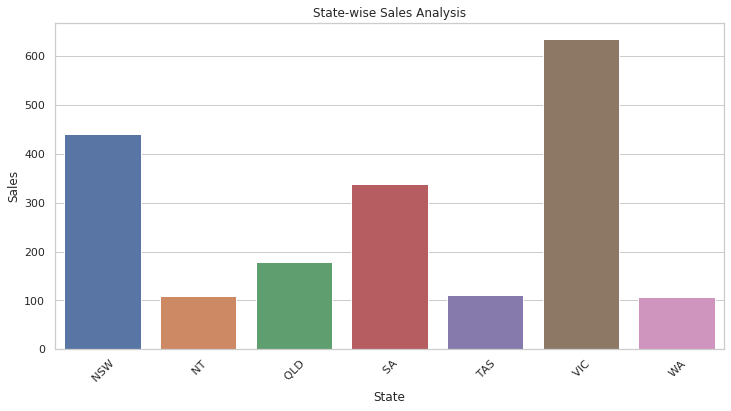

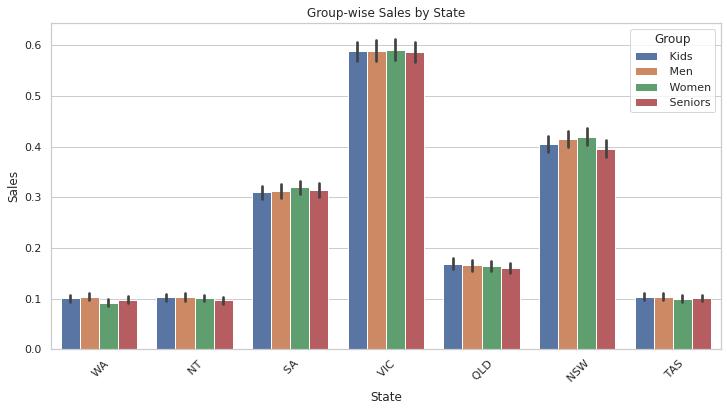

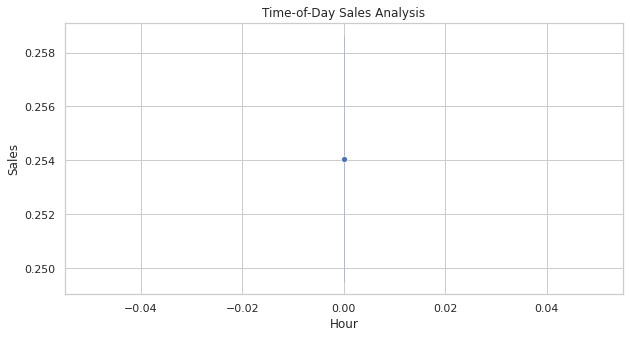

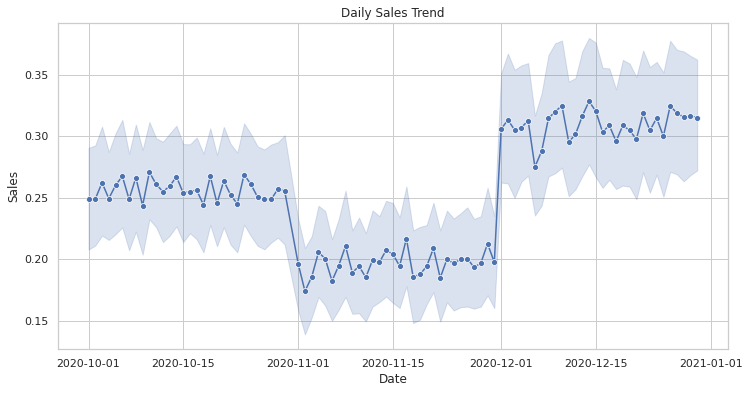

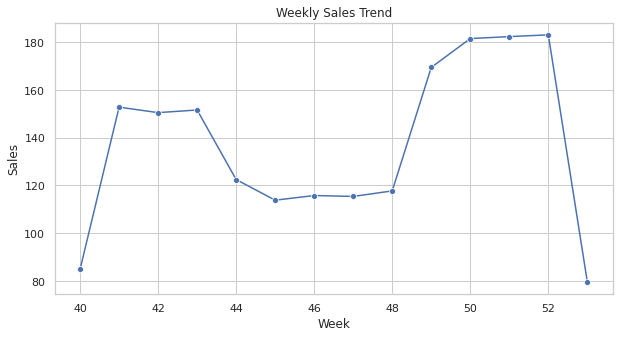

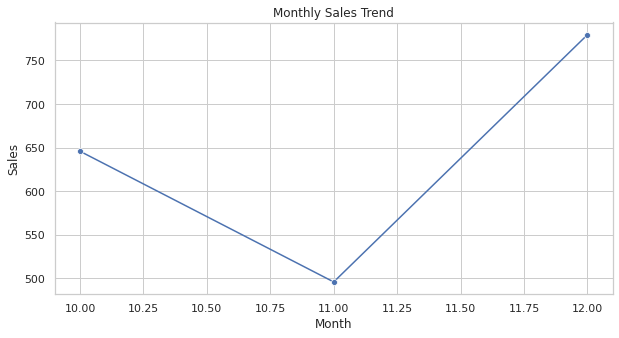

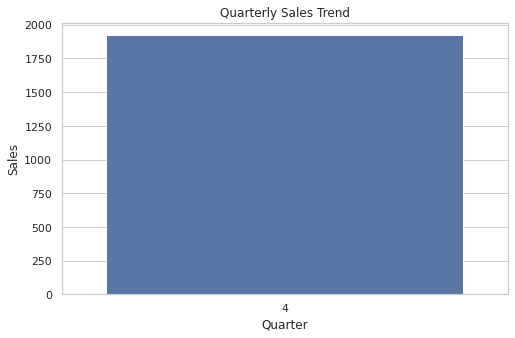

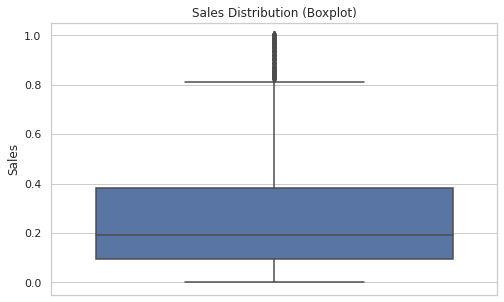

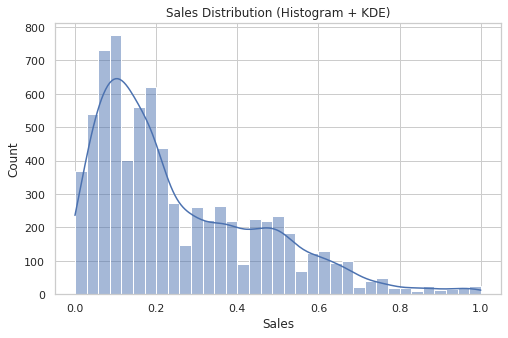

In [8]:
# ---------------------------------------------------------
# 📌 Sales Analysis Project - AAL Clothing Brand
# ---------------------------------------------------------

# Step 1: Import required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Step 2: Load dataset (use your actual file name)
df = pd.read_csv("AusApparalSales4thQrt2020.csv")

# Inspect dataset
print("\n📌 First 5 rows:")
print(df.head())

print("\n📌 Column names:")
print(df.columns.tolist())

print("\n📌 Info:")
print(df.info())

print("\n📌 Missing values:")
print(df.isna().sum())

# Step 3: Handle missing values (choose drop or fill)
df = df.dropna()  # OR use: df.fillna(method='ffill', inplace=True)

# Step 4: Normalization (only normalize existing numeric columns)
scaler = MinMaxScaler()

# Normalize only 'Sales'
if "Sales" in df.columns:
    df[['Sales']] = scaler.fit_transform(df[['Sales']])

# If dataset also has units-like column (edit the name once you know it)
for col in ["Units", "Quantity", "Units_Sold"]:
    if col in df.columns:
        df[[col]] = scaler.fit_transform(df[[col]])

# Step 5: Convert date column
if "Date" in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df['Week'] = df['Date'].dt.isocalendar().week.astype(int)  # Fix: convert to int
    df['Month'] = df['Date'].dt.month
    df['Quarter'] = df['Date'].dt.quarter
    df['Hour'] = df['Date'].dt.hour

# ---------------------------------------------------------
# 2. DATA ANALYSIS
# ---------------------------------------------------------

# Descriptive statistics for Sales
if "Sales" in df.columns:
    print("\n📊 Sales Descriptive Statistics")
    print("Mean:", df['Sales'].mean())
    print("Median:", df['Sales'].median())
    print("Mode:", df['Sales'].mode()[0])
    print("Std Dev:", df['Sales'].std())

# Grouping: State-wise sales
if "State" in df.columns and "Sales" in df.columns:
    state_sales = df.groupby("State")['Sales'].sum().reset_index()
    print("\n📊 State-wise Sales:\n", state_sales)

    highest_sales = state_sales.loc[state_sales['Sales'].idxmax()]
    lowest_sales = state_sales.loc[state_sales['Sales'].idxmin()]
    print("\n✅ Highest Sales State:", highest_sales)
    print("✅ Lowest Sales State:", lowest_sales)

# Grouping: Group-wise sales (Kids, Men, Women, Seniors)
if "Group" in df.columns and "Sales" in df.columns:
    group_sales = df.groupby("Group")['Sales'].sum().reset_index()
    print("\n📊 Group-wise Sales:\n", group_sales)

# Weekly, Monthly, Quarterly reports
if "Date" in df.columns:
    weekly_report = df.groupby('Week')['Sales'].sum().reset_index()
    weekly_report['Week'] = weekly_report['Week'].astype(int)  # Fix dtype
    monthly_report = df.groupby('Month')['Sales'].sum().reset_index()
    quarterly_report = df.groupby('Quarter')['Sales'].sum().reset_index()

    print("\n📊 Weekly Report:\n", weekly_report)
    print("\n📊 Monthly Report:\n", monthly_report)
    print("\n📊 Quarterly Report:\n", quarterly_report)

# ---------------------------------------------------------
# 3. DATA VISUALIZATION
# ---------------------------------------------------------

sns.set(style="whitegrid")

# State-wise sales
if "State" in df.columns and "Sales" in df.columns:
    plt.figure(figsize=(12,6))
    sns.barplot(x="State", y="Sales", data=state_sales)
    plt.title("State-wise Sales Analysis")
    plt.xticks(rotation=45)
    plt.show()

# Group-wise sales across states
if "State" in df.columns and "Group" in df.columns and "Sales" in df.columns:
    plt.figure(figsize=(12,6))
    sns.barplot(x="State", y="Sales", hue="Group", data=df)
    plt.title("Group-wise Sales by State")
    plt.xticks(rotation=45)
    plt.show()

# Time-of-day sales
if "Date" in df.columns:
    plt.figure(figsize=(10,5))
    sns.lineplot(x="Hour", y="Sales", data=df, marker="o")
    plt.title("Time-of-Day Sales Analysis")
    plt.show()

    # Daily trend
    plt.figure(figsize=(12,6))
    sns.lineplot(x="Date", y="Sales", data=df, marker="o")
    plt.title("Daily Sales Trend")
    plt.show()

    # Weekly
    plt.figure(figsize=(10,5))
    sns.lineplot(x="Week", y="Sales", data=weekly_report, marker="o")
    plt.title("Weekly Sales Trend")
    plt.show()

    # Monthly
    plt.figure(figsize=(10,5))
    sns.lineplot(x="Month", y="Sales", data=monthly_report, marker="o")
    plt.title("Monthly Sales Trend")
    plt.show()

    # Quarterly
    plt.figure(figsize=(8,5))
    sns.barplot(x="Quarter", y="Sales", data=quarterly_report)
    plt.title("Quarterly Sales Trend")
    plt.show()

# Boxplot for Sales
if "Sales" in df.columns:
    plt.figure(figsize=(8,5))
    sns.boxplot(y="Sales", data=df)
    plt.title("Sales Distribution (Boxplot)")
    plt.show()

    plt.figure(figsize=(8,5))
    sns.histplot(df['Sales'], kde=True)
    plt.title("Sales Distribution (Histogram + KDE)")
    plt.show()
